# Л1 — Підготовка даних

Велика частина роботи в Data Science — збір і підготовка даних. Саме тут виникає багато неочікуваних проблем і пасток.

Ноутбук нижче базово показує, як працювати з даними й готувати їх. Він не охоплює всіх можливих сценаріїв, а приклади в ньому часом сильно спрощені. Проте він дасть розуміння, де шукати помилки і як з ними боротися. Більше туторіалів — у [Kaggle Learn](https://www.kaggle.com/learn), зокрема [Data Cleaning](https://www.kaggle.com/learn/data-cleaning).

Базовий алгоритм підготовки даних може виглядати так (у дужках — кроки цього ноутбука):

- зчитування даних і початкове дослідження (1);
- дослідження структури й особливостей даних, зміна типів (2);
- об'єднання даних з різних джерел (3–4);
- робота з пропущеними й зламаними значеннями: drop, fill тощо (5, 7, 8);
- пошук outliers: drop, clip тощо (6);
- пошук зайвих і бракуючих колонок (9).

І головне: з кожною дією треба бути обережним. Outliers можуть бути реальними даними, які логічно пояснюються і які не можна видаляти. А пропущені значення можуть щось означати й бути корисними. Обидва випадки є в цій роботі.

Далі бувають кроки, специфічні для певних моделей чи алгоритмів:

- scaling: normalization, standardization тощо;
- обробка категорійних колонок: one-hot encoding тощо;
- dimensionality reduction.

Тут вони не розглядаються, частину з них побачите в Л2 і Л3.

Шаблон веде покроково: у кожному кроці — навіщо він і що зробити, у клітинці з `TODO` — ваш код. Опис даних і таблиця недоліків — у `README.md`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 1. Завантаження даних

На цьому етапі важливо впевнитися, що файли завантажено правильно, і подивитися, що взагалі всередині. Можуть допомогти `df.head()`, `df.tail()`, `df.shape` і `df.dtypes`.

Що ви маєте зрозуміти?

- Чи зчиталися дані взагалі?
- Чи правильно розпарсилися рядки, колонки й значення?
- Які типи в колонок?
- Які приблизно значення?
- Скільки рядків і колонок?

In [2]:
df_meters = pd.read_parquet("meters.parquet")
df_registry = pd.read_csv("registry.csv")

for name, d in [("meters", df_meters), ("registry", df_registry)]:
    print(f"--- {name} ---")
    print(d.shape)
    print(d.dtypes)
    display(d.head())


--- meters ---
(526169, 4)
meter_id                      str
ts                 datetime64[us]
consumption_kwh           float64
record_ts          datetime64[us]
dtype: object


,meter_id,ts,consumption_kwh,record_ts
0,UA100900,2026-01-05 00:00:00,0.1257,2026-01-05 00:01:52
1,UA100900,2026-01-05 01:00:00,0.1173,2026-01-05 01:06:56
2,UA100900,2026-01-05 02:00:00,0.1415,2026-01-05 02:14:19
3,UA100900,2026-01-05 03:00:00,0.1401,2026-01-05 03:03:01
4,UA100900,2026-01-05 04:00:00,0.1149,2026-01-05 04:13:02


--- registry ---
(800, 7)
meter_id              str
customer_type         str
tariff                str
electric_heating    int64
connection_year     int64
years_connected     int64
district              str
dtype: object


,meter_id,customer_type,tariff,electric_heating,connection_year,years_connected,district
0,UA100900,household,single,0,2006,20,Solomianka
1,UA101907,small_business,dual_zone,0,2001,25,Obolon
2,UA102894,household,single,0,2008,17,Sviatoshyn
3,UA103276,household,single,0,1998,27,Solomianka
4,UA104249,household,dual_zone,1,1988,37,Obolon


## 2. Звірка з описом

Іноді бізнес надає опис ідеальних даних, але реальні дані часто з ним не збігаються. Тому спершу подивіться, чи ваші дані відповідають опису в `README.md`. Може допомогти `df.describe()`.

Перевірте (але поки не виправляйте):

- типи колонок: якщо число прочиталося як текст, частина операцій спрацює неправильно;
- скільки рядків мають `customer_type`, `tariff` чи `electric_heating`, яких немає в описі;
- скільки рядків мають `ts`, `connection_year` чи `years_connected` поза межами з опису;
- скільки різних лічильників у кожному файлі — мають бути по 800.

Можуть допомогти `isin`, `between` і `nunique`.

Недоліки з таблиці в `README.md` перевірятимете далі, кожен у своєму кроці. Межі споживання залежать від типу абонента, а тип є лише в реєстрі, тому їх перевірите після об'єднання, на кроці 6.

In [3]:
print("customer_type valid:", df_registry["customer_type"].isin(["household","small_business","industrial"]).value_counts().to_dict())
print("tariff valid:", df_registry["tariff"].isin(["single","dual_zone"]).value_counts().to_dict())
print("electric_heating valid:", df_registry["electric_heating"].isin([0,1]).value_counts().to_dict())
print("ts in range:", df_meters["ts"].between("2026-01-05 00:00","2026-02-01 23:00").value_counts().to_dict())
print("connection_year in range:", df_registry["connection_year"].between(1985,2024).value_counts().to_dict())
print("years_connected in range:", df_registry["years_connected"].between(1,41).value_counts().to_dict())
print("nunique meters (meters, registry):", df_meters["meter_id"].nunique(), df_registry["meter_id"].nunique())


customer_type valid: {True: 800}
tariff valid: {True: 800}
electric_heating valid: {True: 800}
ts in range: {True: 526169}
connection_year in range: {True: 800}
years_connected in range: {True: 800}
nunique meters (meters, registry): 800 800


## 3. Реєстр: номери й райони (D-E, D-F)

Дані зберігаються в різних системах, тому формат ідентифікатора може не збігатися: `" UA123456"` для pandas — інший номер, ніж `UA123456`. Наївний join призведе до того, що частина даних втратиться. Так само `podil` і `Podil` — різні райони, і будь-який підрахунок по районах буде хибним.

Для D-E і D-F виведіть, скільки рядків реєстру зіпсовано, і виправте їх так, як сказано в таблиці недоліків. Можуть допомогти `str.fullmatch(r"UA\d{6}")`, `isin`, `str.strip()`, `str.lstrip("0")` і `str.capitalize()`.

In [4]:
# D-E — формат meter_id
bad_id = ~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")
print("зіпсованих номерів:", bad_id.sum())
df_registry["meter_id"] = df_registry["meter_id"].str.strip().str.replace(r"^0+(?=UA)", "", regex=True)
assert df_registry["meter_id"].str.fullmatch(r"UA\d{6}").all()

# D-F — район
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
bad_district = ~df_registry["district"].isin(districts)
print("рядків з неправильним district:", bad_district.sum())
df_registry["district"] = df_registry["district"].str.strip().str.capitalize()
assert df_registry["district"].isin(districts).all()


зіпсованих номерів: 0
рядків з неправильним district: 80


## 4. Об'єднання

Тепер погодинні дані можна об'єднати з реєстром за `meter_id` (join, у pandas — `merge`). pandas не попереджає, коли рядок не знайшов пари, тому якість об'єднання треба перевірити самому.

Об'єднану таблицю назвіть `df`, з нею працюватимете далі. Перевірте й виведіть:

- кількість рядків до і після об'єднання — вона не має змінитися;
- кількість рядків без атрибутів абонента (пропуск у `customer_type`) — має бути 0.

Може допомогти `merge(..., how="left", validate="m:1")`: `validate` ще й перевірить, що кожному лічильнику відповідає один рядок реєстру.

In [5]:
df = df_meters.merge(df_registry, on="meter_id", how="left", validate="m:1")
print("рядків до об'єднання:", len(df_meters), "після:", len(df))
print("рядків без customer_type:", df["customer_type"].isna().sum())


рядків до об'єднання: 526169 після: 526169
рядків без customer_type: 0


## 5. Повторні відправки (D-C)

Повторна відправка — та сама година того самого лічильника ще раз, іноді з уточненим значенням. Якщо лишити обидва записи, споживання за цю годину подвоїться. Лишаємо найпізніший за `record_ts` запис як найсвіжіший.

Виведіть кількість рядків і кількість різних пар `meter_id` і `ts`, потім зніміть повтори. Можуть допомогти `duplicated(["meter_id", "ts"])`, `sort_values("record_ts")` і `drop_duplicates(["meter_id", "ts"], keep="last")`.

In [6]:
print("рядків:", len(df))
print("унікальних пар meter_id+ts:", df[["meter_id", "ts"]].drop_duplicates().shape[0])

df = df.sort_values("record_ts").drop_duplicates(["meter_id", "ts"], keep="last")
print("рядків після зняття повторів:", len(df))


рядків: 526169


унікальних пар meter_id+ts: 515964


рядків після зняття повторів: 515964


## 6. Одиниці виміру (D-D)

Значення у Вт·год схожі на викиди, але це не шум, а помилка одиниць. Якщо їх видалити, зникнуть цілі абоненти.

1. Для кожного лічильника порахуйте відношення його медіани `consumption_kwh` до медіани всіх рядків його `customer_type`. Більше 100 — лічильник звітує у Вт·год.
2. Побудуйте графік медіан лічильників за `customer_type` з логарифмічною віссю, наприклад boxplot.
3. Виведіть кількість лічильників у Вт·год, найбільше відношення серед решти лічильників і найменше серед лічильників у Вт·год (якщо таких немає — лише найбільше відношення серед усіх). Ці числа — доказ у звіті: вони показують, наскільки далеко від порога обидві групи.
4. Поділіть значення цих лічильників на 1000 і виведіть, скільки рядків поза межами споживання з опису, — має бути 0.

Можуть допомогти `DataFrame.boxplot(column=..., by="customer_type")`, `plt.yscale("log")` і `between`. Клітинку з діленням не запускайте двічі: значення поділяться ще раз. Якщо так сталося, перезапустіть ноутбук з початку.

лічильників у Вт·год: 64
найбільший ratio серед решти: 5.2854312637080625
найменший ratio серед Вт·год: 236.45815864497735


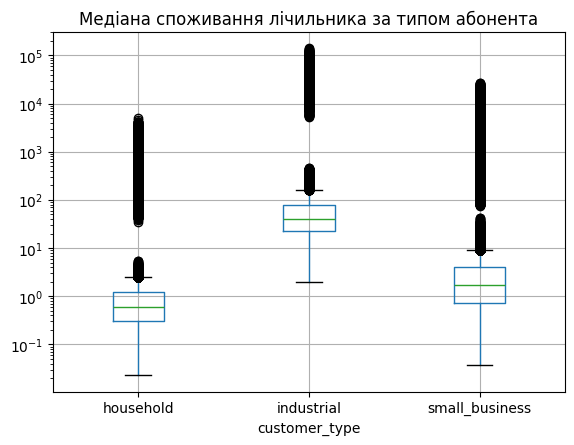

поза межами споживання після виправлення: 0


In [7]:
meter_median = df.groupby("meter_id")["consumption_kwh"].median()
meter_type = df.groupby("meter_id")["customer_type"].first()
type_median = df.groupby("customer_type")["consumption_kwh"].median()
ratio = meter_median / meter_type.map(type_median)

wrong_units = ratio[ratio > 100].index
print("лічильників у Вт·год:", len(wrong_units))
print("найбільший ratio серед решти:", ratio.drop(wrong_units).max())
if len(wrong_units):
    print("найменший ratio серед Вт·год:", ratio[wrong_units].min())

df.boxplot(column="consumption_kwh", by="customer_type")
plt.yscale("log")
plt.title("Медіана споживання лічильника за типом абонента")
plt.suptitle("")
plt.show()

df.loc[df["meter_id"].isin(wrong_units), "consumption_kwh"] /= 1000

min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
out_of_range = ~df["consumption_kwh"].between(df["customer_type"].map(min_kwh), df["customer_type"].map(max_kwh))
print("поза межами споживання після виправлення:", out_of_range.sum())


## 7. Лічильники, що замовкли (D-A)

Пропуски не заповнюємо: те, що лічильник замовк, уже є інформацією про можливу відмову, а середнє її стерло б. Не видаляємо теж: до відмови лічильник передавав правильні дані.

Для кожного лічильника порахуйте, скільки годин минуло від його останнього `ts` до `2026-02-01 23:00`; більше 48 — замовк. Як на кроці 6, виведіть кількість замовклих, найбільшу тишу серед решти й найменшу серед замовклих (якщо замовклих немає — лише найбільшу тишу серед усіх).

Номери замовклих лічильників збережіть списком `silent`, наприклад `list(....index)`: він знадобиться в регресії.

Можуть допомогти `pd.Timestamp("2026-02-01 23:00")` і `/ pd.Timedelta(hours=1)`.

In [8]:
last_ts = df.groupby("meter_id")["ts"].max()
gap_hours = (pd.Timestamp("2026-02-01 23:00") - last_ts) / pd.Timedelta(hours=1)

silent = gap_hours[gap_hours > 48].index.tolist()
print("замовклих лічильників:", len(silent))
print("найбільша тиша серед решти (год):", gap_hours.drop(silent).max())
if silent:
    print("найменша тиша серед замовклих (год):", gap_hours[silent].min())


замовклих лічильників: 48
найбільша тиша серед решти (год): 1.0
найменша тиша серед замовклих (год): 155.0


## 8. Завмерлі лічильники (D-B)

Завмерлі значення виглядають правдоподібно, і ні середнє, ні максимум їх не видають. Помітно лише те, що значення перестали змінюватися. Такі лічильники не видаляємо: частина їхніх годин справна.

Для кожного лічильника порахуйте частку різних значень `consumption_kwh` серед його записів; менше 0.65 — завмер. Побудуйте гістограму цієї частки по лічильниках. Як на кроці 6, виведіть кількість завмерлих, найменшу частку серед решти й найбільшу серед завмерлих (якщо завмерлих немає — лише найменшу частку серед усіх).

Номери завмерлих лічильників збережіть списком `frozen`: він знадобиться в регресії.

Можуть допомогти `nunique()`, `size()` і `plt.hist`.

завмерлих лічильників: 40
найменша частка серед решти: 0.8418674698795181
найбільша частка серед завмерлих: 0.48717948717948717


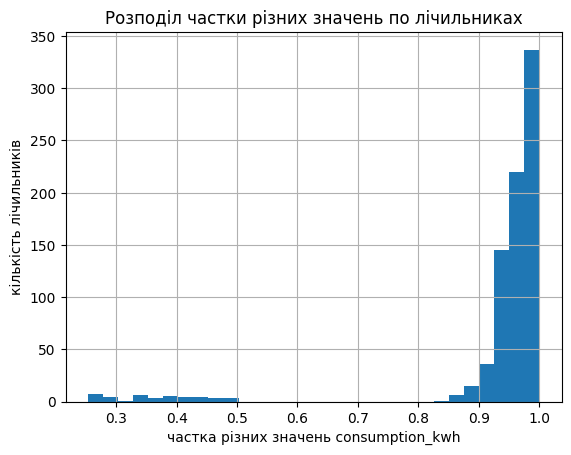

In [9]:
nunique_share = df.groupby("meter_id")["consumption_kwh"].apply(lambda s: s.nunique() / s.size)

frozen = nunique_share[nunique_share < 0.65].index.tolist()
print("завмерлих лічильників:", len(frozen))
print("найменша частка серед решти:", nunique_share.drop(frozen).min())
if frozen:
    print("найбільша частка серед завмерлих:", nunique_share[frozen].max())

nunique_share.hist(bins=30)
plt.xlabel("частка різних значень consumption_kwh")
plt.ylabel("кількість лічильників")
plt.title("Розподіл частки різних значень по лічильниках")
plt.show()


## 9. Кореляції

Колонка, що майже копіює іншу, не додає інформації: у кластеризації вона подвоює вагу того самого фактора, а в регресії робить коефіцієнти нестабільними. Технічна колонка `record_ts` після кроку 5 теж не потрібна.

Порахуйте кореляції між числовими колонками об'єднаної таблиці. Пару з кореляцією за модулем понад 0.95 вважайте копією і лиште з неї одну колонку. Приберіть `record_ts`. Підсумкову таблицю назвіть `result`.

Можуть допомогти `select_dtypes("number").corr().abs()` і `drop(columns=...)`.

In [10]:
corr = df.select_dtypes("number").corr().abs()
copies = [(a, b) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]
print("колонки-копії (|corr| > 0.95):", copies)
print(corr)

drop_cols = ["record_ts"] + [b for a, b in copies]
result = df.drop(columns=drop_cols)
print("result shape:", result.shape)
print("result columns:", list(result.columns))


колонки-копії (|corr| > 0.95): [('connection_year', 'years_connected')]
                  consumption_kwh  electric_heating  connection_year  \
consumption_kwh          1.000000          0.106507         0.056394   
electric_heating         0.106507          1.000000         0.018646   
connection_year          0.056394          0.018646         1.000000   
years_connected          0.057085          0.016613         0.999062   

                  years_connected  
consumption_kwh          0.057085  
electric_heating         0.016613  
connection_year          0.999062  
years_connected          1.000000  
result shape: (515964, 8)
result columns: ['meter_id', 'ts', 'consumption_kwh', 'customer_type', 'tariff', 'electric_heating', 'connection_year', 'district']


## 10. Самоперевірка й збереження

Якщо якась перевірка падає, поверніться до відповідного кроку.

In [11]:
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
corr = result.select_dtypes("number").corr().abs()
copies = [(a, b) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]

assert not result.duplicated(["meter_id", "ts"]).any(), "лишилися повтори лічильник–година"
assert result["meter_id"].nunique() == 800, "лічильників має бути 800"
assert result["meter_id"].str.fullmatch(r"UA\d{6}").all(), "є номери не у форматі UA і 6 цифр"
assert result["customer_type"].notna().all(), "є рядки без атрибутів абонента"
assert result["district"].isin(districts).all(), "є райони, яких немає в описі"
assert result["consumption_kwh"].between(result["customer_type"].map(min_kwh), result["customer_type"].map(max_kwh)).all(), "є споживання поза межами з опису"
assert not copies, f"лишилися колонки-копії: {copies}"
assert "record_ts" not in result, "технічна колонка record_ts лишилася"

result.to_parquet("cleaned.parquet", index=False)
print("усе гаразд:", result.shape)

усе гаразд: (515964, 8)


## 11. Регресія

Регресію часто використовують, щоб передбачати певні показники. Проте лінійна регресія також показує, як кожен показник впливає на результат. Це і є регресійний аналіз.

Для прикладу подивимося, як на добове споживання домогосподарства впливають електроопалення і двозонний тариф: `y = a + b₁·x₁ + b₂·x₂`.

- `y` — середнє споживання лічильника за добу, кВт·год;
- `x₁` — `electric_heating`, `x₂` — двозонний тариф (обидва 0 або 1);
- `b₁` і `b₂` — на скільки кВт·год на добу більше споживає абонент із цим фактором за однакового іншого;
- `a` — споживання без опалення на звичайному тарифі;
- R² — яку частку розкиду споживання пояснюють обидва фактори, від 0 до 1.

Регресія тут краща за просте порівняння середніх: двозонний тариф здебільшого мають будинки з опаленням, і різниця середніх за тарифом приписала б тарифу ще й споживання на опалення.

Нормалізація не потрібна: обидва фактори мають однаковий масштаб (0 або 1), тож `b₁` і `b₂` можна порівнювати напряму, а `y` лишається в кВт·год на добу, і коефіцієнти легко пояснити. Якби фактори мали різні одиниці, наприклад площу і рік, для порівняння впливу їх спершу стандартизували б.

Лічильники з `silent` і `frozen` не беремо: у `cleaned.parquet` вони лишаються, але їхнє середнє споживання спотворене.

Код майже готовий: допишіть `homes` і запустіть.

In [12]:
homes = result[(result["customer_type"] == "household")
               & ~(result["meter_id"].isin(silent))
               & ~(result["meter_id"].isin(frozen))]

per_meter = homes.groupby("meter_id").agg(
    kwh_per_day=("consumption_kwh", "mean"),
    electric_heating=("electric_heating", "first"),
    tariff=("tariff", "first"),
)
per_meter["kwh_per_day"] *= 24
per_meter["dual_zone"] = (per_meter["tariff"] == "dual_zone").astype(int)

x, y = per_meter[["electric_heating", "dual_zone"]], per_meter["kwh_per_day"]
model = LinearRegression().fit(x, y)
print("лічильників:", len(per_meter))
print(f"a = {model.intercept_:.2f}, b₁ (опалення) = {model.coef_[0]:.2f}, b₂ (двозонний тариф) = {model.coef_[1]:.2f}, R² = {model.score(x, y):.3f}")


лічильників: 469
a = 10.71, b₁ (опалення) = 19.35, b₂ (двозонний тариф) = 3.13, R² = 0.702
